# Visualize SCREAM and HRRR Grid Points

This notebook visualizes the grid points from E3SM SCREAM (spectral element) and HRRR (Lambert Conformal) grids over northern Alabama near Huntsville.

- SCREAM: ~3.25 km unstructured grid
- HRRR: ~3 km structured grid

In [12]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from pyproj import Transformer

## Load Data

In [13]:
# File paths
SCREAM_FILE = '/pscratch/sd/w/wcmca1/SCREAMv1-cess2/run_conus/output.scream.diag_equiv_reflectivity.5min.INSTANT.nmins_x5.2020-06-06-79500.nc'
HRRR_GRID_FILE = '/global/cfs/cdirs/m1657/zfeng/SEUS/hrrr_sfc_latlon.nc'

# Load SCREAM data
print("Loading SCREAM data...")
ds_scream = xr.open_dataset(SCREAM_FILE)
scream_lat = ds_scream['lat'].values
scream_lon = ds_scream['lon'].values
print(f"  SCREAM: {len(scream_lat)} grid points")
print(f"  Lat range: {scream_lat.min():.2f} to {scream_lat.max():.2f}°")
print(f"  Lon range: {scream_lon.min():.2f} to {scream_lon.max():.2f}°")

# Load HRRR grid
print("\nLoading HRRR grid...")
ds_hrrr = xr.open_dataset(HRRR_GRID_FILE)
hrrr_lat = ds_hrrr['latitude'].values
hrrr_lon = ds_hrrr['longitude'].values
print(f"  HRRR: {hrrr_lat.shape} grid shape")
print(f"  Lat range: {hrrr_lat.min():.2f} to {hrrr_lat.max():.2f}°")
print(f"  Lon range: {hrrr_lon.min():.2f} to {hrrr_lon.max():.2f}°")

Loading SCREAM data...
  SCREAM: 786454 grid points
  Lat range: 24.00 to 50.00°
  Lon range: 235.00 to 294.00°

Loading HRRR grid...
  HRRR: (1059, 1799) grid shape
  Lat range: 21.14 to 52.62°
  Lon range: 225.90 to 299.08°


/tmp/ipykernel_1932290/3850950783.py:16: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_hrrr = xr.open_dataset(HRRR_GRID_FILE)


SCREAM bounds:
  Lat: 24.00° to 50.00°
  Lon: 235.00° to 294.00°

Reduced HRRR indices (southern buffer: 1.5°, eastern buffer: -3°):
  Y (lat) range: [55:959] (of 1059)
  X (lon) range: [240:1585] (of 1799)
  Reduced grid shape: 904 × 1345

Reduced HRRR boundary check:
  Min lat across all reduced points: 23.87°
  Max lat across all reduced points: 49.99°
  Min lon across all reduced points: 236.17°
  Max lon across all reduced points: 289.80°

Reduced HRRR corner coordinates:
  SW: (24.01°N, 243.48°E)
  SE: (23.87°N, 282.24°E)
  NE: (47.28°N, 289.80°E)
  NW: (47.47°N, 236.17°E)

Original HRRR Grid Corners:
  SW: (21.14°N, 237.28°E) -> (-2692368 m, -1390071 m)
  SE: (21.14°N, 287.71°E) -> (2692648 m, -1389701 m)
  NE: (47.84°N, 299.08°E) -> (2683431 m, 1762986 m)
  NW: (47.84°N, 225.90°E) -> (-2683588 m, 1762618 m)

Total ORIGINAL HRRR edge points: 5712
Total REDUCED HRRR edge points: 4494


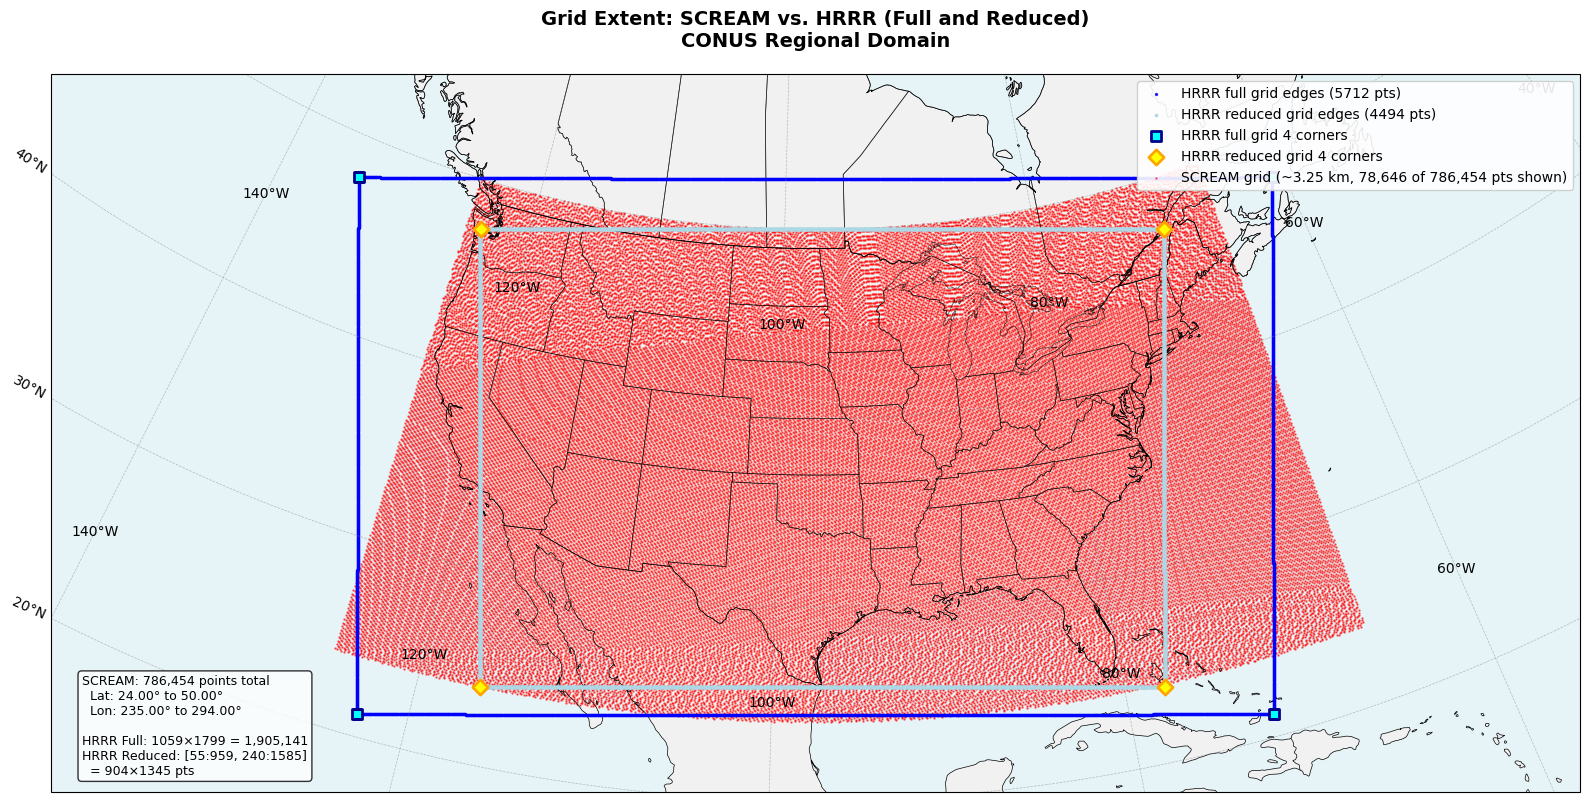


SUMMARY:
SCREAM Grid Bounds:
  Latitude:  24.00° to 50.00°
  Longitude: 235.00° to 294.00°

HRRR Full Grid: 1059 × 1799

HRRR Reduced Grid Indices:
  Buffers: southern=1.5°, eastern=-3°
  Y (rows):    [55:959]
  X (columns): [240:1585]
  Shape: 904 × 1345

Python slicing:
  hrrr_lat_reduced = hrrr_lat[55:959, 240:1585]
  hrrr_lon_reduced = hrrr_lon[55:959, 240:1585]


In [30]:
# Create figure showing full extent of both grids
fig = plt.figure(figsize=(16, 12))

# Use Lambert Conformal projection (native HRRR projection)
# Central coordinates for CONUS
central_lon = (hrrr_lon.min() + hrrr_lon.max()) / 2
central_lat = (hrrr_lat.min() + hrrr_lat.max()) / 2

proj = ccrs.LambertConformal(
    central_longitude=central_lon,
    central_latitude=central_lat,
    standard_parallels=(33, 45)
)

ax = plt.axes(projection=proj)

# Set extent to cover both grids with some padding
# ax.set_extent([220, 305, 18, 55], crs=ccrs.PlateCarree())
ax.set_extent([220, 305, 20, 52], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.5, edgecolor='black', alpha=0.7)
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth=0.5)
ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', alpha=0.3)
ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='lightblue', alpha=0.3)

# Get SCREAM min/max lat/lon bounds
scream_lat_min = scream_lat.min()
scream_lat_max = scream_lat.max()
scream_lon_min = scream_lon.min()
scream_lon_max = scream_lon.max()

print(f"SCREAM bounds:")
print(f"  Lat: {scream_lat_min:.2f}° to {scream_lat_max:.2f}°")
print(f"  Lon: {scream_lon_min:.2f}° to {scream_lon_max:.2f}°")

# Find HRRR indices that fit within SCREAM bounds
# Since HRRR is curvilinear, we need to check points along each edge
# Allow buffers to extend boundaries for better coverage
southern_buffer = 1.5  # degrees - extend southern border to capture Florida/Texas
eastern_buffer = -3   # degrees - extend eastern border if needed

# Find y_min_idx (southern border): first row where min lat >= scream_lat_min - buffer
# This allows the row to extend further south to capture Florida and Texas
y_min_idx = None
for y in range(hrrr_lat.shape[0]):
    if hrrr_lat[y, :].min() >= (scream_lat_min - southern_buffer):
        y_min_idx = y
        break

# Find y_max_idx (northern border): last row where max lat <= scream_lat_max
# This ensures no part of the row extends beyond SCREAM's northern limit
y_max_idx = None
for y in range(hrrr_lat.shape[0] - 1, -1, -1):
    if hrrr_lat[y, :].max() <= scream_lat_max:
        y_max_idx = y
        break

# Find x_min_idx (western border): first column where min lon >= scream_lon_min
x_min_idx = None
for x in range(hrrr_lon.shape[1]):
    if hrrr_lon[:, x].min() >= scream_lon_min:
        x_min_idx = x
        break

# Find x_max_idx (eastern border): last column where max lon <= scream_lon_max + buffer
# Allow eastern extension with buffer
x_max_idx = None
for x in range(hrrr_lon.shape[1] - 1, -1, -1):
    if hrrr_lon[:, x].max() <= (scream_lon_max + eastern_buffer):
        x_max_idx = x
        break

print(f"\nReduced HRRR indices (southern buffer: {southern_buffer}°, eastern buffer: {eastern_buffer}°):")
print(f"  Y (lat) range: [{y_min_idx}:{y_max_idx+1}] (of {hrrr_lat.shape[0]})")
print(f"  X (lon) range: [{x_min_idx}:{x_max_idx+1}] (of {hrrr_lat.shape[1]})")
print(f"  Reduced grid shape: {y_max_idx - y_min_idx + 1} × {x_max_idx - x_min_idx + 1}")

# Verify the reduced grid boundaries
print(f"\nReduced HRRR boundary check:")
print(f"  Min lat across all reduced points: {hrrr_lat[y_min_idx:y_max_idx+1, x_min_idx:x_max_idx+1].min():.2f}°")
print(f"  Max lat across all reduced points: {hrrr_lat[y_min_idx:y_max_idx+1, x_min_idx:x_max_idx+1].max():.2f}°")
print(f"  Min lon across all reduced points: {hrrr_lon[y_min_idx:y_max_idx+1, x_min_idx:x_max_idx+1].min():.2f}°")
print(f"  Max lon across all reduced points: {hrrr_lon[y_min_idx:y_max_idx+1, x_min_idx:x_max_idx+1].max():.2f}°")

# Get the 4 corners of the ORIGINAL HRRR grid in lat/lon
corners_lat = np.array([
    hrrr_lat[0, 0],      # bottom-left (SW)
    hrrr_lat[0, -1],     # bottom-right (SE)
    hrrr_lat[-1, -1],    # top-right (NE)
    hrrr_lat[-1, 0],     # top-left (NW)
])
corners_lon = np.array([
    hrrr_lon[0, 0],      # bottom-left (SW)
    hrrr_lon[0, -1],     # bottom-right (SE)
    hrrr_lon[-1, -1],    # top-right (NE)
    hrrr_lon[-1, 0],     # top-left (NW)
])

# Get the 4 corners of the REDUCED HRRR grid
reduced_corners_lat = np.array([
    hrrr_lat[y_min_idx, x_min_idx],      # bottom-left (SW)
    hrrr_lat[y_min_idx, x_max_idx],      # bottom-right (SE)
    hrrr_lat[y_max_idx, x_max_idx],      # top-right (NE)
    hrrr_lat[y_max_idx, x_min_idx],      # top-left (NW)
])
reduced_corners_lon = np.array([
    hrrr_lon[y_min_idx, x_min_idx],      # bottom-left (SW)
    hrrr_lon[y_min_idx, x_max_idx],      # bottom-right (SE)
    hrrr_lon[y_max_idx, x_max_idx],      # top-right (NE)
    hrrr_lon[y_max_idx, x_min_idx],      # top-left (NW)
])

print(f"\nReduced HRRR corner coordinates:")
for i, name in enumerate(['SW', 'SE', 'NE', 'NW']):
    print(f"  {name}: ({reduced_corners_lat[i]:.2f}°N, {reduced_corners_lon[i]:.2f}°E)")

# Transform HRRR corner lat/lon to projection coordinates (meters)
proj_crs = proj.proj4_init
transformer = Transformer.from_crs("EPSG:4326", proj_crs, always_xy=True)
corners_x, corners_y = transformer.transform(corners_lon, corners_lat)

print("\nOriginal HRRR Grid Corners:")
for i, name in enumerate(['SW', 'SE', 'NE', 'NW']):
    print(f"  {name}: ({corners_lat[i]:.2f}°N, {corners_lon[i]:.2f}°E) -> ({corners_x[i]:.0f} m, {corners_y[i]:.0f} m)")

# # Draw 4 straight lines in projection space (perfect rectangle)
# for i in range(4):
#     ax.plot([corners_x[i], corners_x[(i+1)%4]], 
#             [corners_y[i], corners_y[(i+1)%4]], 
#             color='blue', linewidth=3, alpha=0.8,
#             transform=proj,
#             zorder=2)

# # Add label for the boundary (just once)
# ax.plot([], [], color='blue', linewidth=3, alpha=0.8,
#         label=f'HRRR grid boundary ({hrrr_lat.shape[0]}×{hrrr_lat.shape[1]})')

# Plot all ORIGINAL HRRR edge points as blue dots
# Bottom edge
edge_lat_bottom = hrrr_lat[0, :]
edge_lon_bottom = hrrr_lon[0, :]
# Top edge
edge_lat_top = hrrr_lat[-1, :]
edge_lon_top = hrrr_lon[-1, :]
# Left edge (excluding corners to avoid duplicates)
edge_lat_left = hrrr_lat[1:-1, 0]
edge_lon_left = hrrr_lon[1:-1, 0]
# Right edge (excluding corners to avoid duplicates)
edge_lat_right = hrrr_lat[1:-1, -1]
edge_lon_right = hrrr_lon[1:-1, -1]

# Combine all edges
all_edge_lat = np.concatenate([edge_lat_bottom, edge_lat_top, edge_lat_left, edge_lat_right])
all_edge_lon = np.concatenate([edge_lon_bottom, edge_lon_top, edge_lon_left, edge_lon_right])

print(f"\nTotal ORIGINAL HRRR edge points: {len(all_edge_lat)}")

# Plot edge points as blue dots
ax.scatter(
    all_edge_lon, all_edge_lat,
    c='blue', s=2, marker='o', alpha=0.8,
    transform=ccrs.PlateCarree(),
    label=f'HRRR full grid edges ({len(all_edge_lat)} pts)',
    zorder=2,
    rasterized=True
)

# Plot all REDUCED HRRR edge points as light blue dots
# Bottom edge
reduced_edge_lat_bottom = hrrr_lat[y_min_idx, x_min_idx:x_max_idx+1]
reduced_edge_lon_bottom = hrrr_lon[y_min_idx, x_min_idx:x_max_idx+1]
# Top edge
reduced_edge_lat_top = hrrr_lat[y_max_idx, x_min_idx:x_max_idx+1]
reduced_edge_lon_top = hrrr_lon[y_max_idx, x_min_idx:x_max_idx+1]
# Left edge (excluding corners)
reduced_edge_lat_left = hrrr_lat[y_min_idx+1:y_max_idx, x_min_idx]
reduced_edge_lon_left = hrrr_lon[y_min_idx+1:y_max_idx, x_min_idx]
# Right edge (excluding corners)
reduced_edge_lat_right = hrrr_lat[y_min_idx+1:y_max_idx, x_max_idx]
reduced_edge_lon_right = hrrr_lon[y_min_idx+1:y_max_idx, x_max_idx]

# Combine all reduced edges
all_reduced_edge_lat = np.concatenate([reduced_edge_lat_bottom, reduced_edge_lat_top, 
                                        reduced_edge_lat_left, reduced_edge_lat_right])
all_reduced_edge_lon = np.concatenate([reduced_edge_lon_bottom, reduced_edge_lon_top, 
                                        reduced_edge_lon_left, reduced_edge_lon_right])

print(f"Total REDUCED HRRR edge points: {len(all_reduced_edge_lat)}")

# Plot reduced edge points as light blue dots
ax.scatter(
    all_reduced_edge_lon, all_reduced_edge_lat,
    c='lightblue', s=3, marker='o', alpha=0.9,
    transform=ccrs.PlateCarree(),
    label=f'HRRR reduced grid edges ({len(all_reduced_edge_lat)} pts)',
    zorder=3,
    rasterized=True
)

# Plot the 4 corners of ORIGINAL grid as larger markers for reference
ax.scatter(
    corners_lon, corners_lat,
    c='cyan', s=50, marker='s', alpha=1.0,
    edgecolors='darkblue', linewidths=2,
    transform=ccrs.PlateCarree(),
    label='HRRR full grid 4 corners',
    zorder=4
)

# Plot the 4 corners of REDUCED grid
ax.scatter(
    reduced_corners_lon, reduced_corners_lat,
    c='yellow', s=60, marker='D', alpha=1.0,
    edgecolors='orange', linewidths=2,
    transform=ccrs.PlateCarree(),
    label='HRRR reduced grid 4 corners',
    zorder=5
)

# Plot SCREAM grid (sample for performance)
sample_rate_scream = 10
scream_lat_sample = scream_lat[::sample_rate_scream]
scream_lon_sample = scream_lon[::sample_rate_scream]

ax.scatter(
    scream_lon_sample, scream_lat_sample,
    c='red', s=0.5, marker='o', alpha=0.6,
    transform=ccrs.PlateCarree(),
    label=f'SCREAM grid (~3.25 km, {len(scream_lat_sample):,} of {len(scream_lat):,} pts shown)',
    rasterized=True,
    zorder=1
)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Add legend
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)

# Add title
plt.title(
    'Grid Extent: SCREAM vs. HRRR (Full and Reduced)\nCONUS Regional Domain',
    fontsize=14, fontweight='bold', pad=20
)

# Add text with grid statistics
stats_text = f'SCREAM: {len(scream_lat):,} points total\n'
stats_text += f'  Lat: {scream_lat_min:.2f}° to {scream_lat_max:.2f}°\n'
stats_text += f'  Lon: {scream_lon_min:.2f}° to {scream_lon_max:.2f}°\n\n'
stats_text += f'HRRR Full: {hrrr_lat.shape[0]}×{hrrr_lat.shape[1]} = {hrrr_lat.size:,}\n'
stats_text += f'HRRR Reduced: [{y_min_idx}:{y_max_idx+1}, {x_min_idx}:{x_max_idx+1}]\n'
stats_text += f'  = {y_max_idx - y_min_idx + 1}×{x_max_idx - x_min_idx + 1} pts'
ax.text(0.02, 0.02, stats_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"SUMMARY:")
print(f"{'='*60}")
print(f"SCREAM Grid Bounds:")
print(f"  Latitude:  {scream_lat_min:.2f}° to {scream_lat_max:.2f}°")
print(f"  Longitude: {scream_lon_min:.2f}° to {scream_lon_max:.2f}°")
print(f"\nHRRR Full Grid: {hrrr_lat.shape[0]} × {hrrr_lat.shape[1]}")
print(f"\nHRRR Reduced Grid Indices:")
print(f"  Buffers: southern={southern_buffer}°, eastern={eastern_buffer}°")
print(f"  Y (rows):    [{y_min_idx}:{y_max_idx+1}]")
print(f"  X (columns): [{x_min_idx}:{x_max_idx+1}]")
print(f"  Shape: {y_max_idx - y_min_idx + 1} × {x_max_idx - x_min_idx + 1}")
print(f"\nPython slicing:")
print(f"  hrrr_lat_reduced = hrrr_lat[{y_min_idx}:{y_max_idx+1}, {x_min_idx}:{x_max_idx+1}]")
print(f"  hrrr_lon_reduced = hrrr_lon[{y_min_idx}:{y_max_idx+1}, {x_min_idx}:{x_max_idx+1}]")
print(f"{'='*60}")

## Define Region of Interest

Northern Alabama near Huntsville (34.7°N, 86.6°W = 273.4°E)

In [3]:
# Region around Huntsville, Alabama
# Make the box small enough to see individual grid points
lat_center = 34.7
lon_center = 273.4  # -86.6°W in 0-360 format

# Small region: ~50 km box (about 0.5 degrees at this latitude)
lat_min, lat_max = lat_center - 0.25, lat_center + 0.25
lon_min, lon_max = lon_center - 0.3, lon_center + 0.3

print(f"Region of interest:")
print(f"  Latitude: {lat_min:.2f} to {lat_max:.2f}°N")
print(f"  Longitude: {lon_min:.2f} to {lon_max:.2f}°E ({lon_min-360:.2f} to {lon_max-360:.2f}°W)")

Region of interest:
  Latitude: 34.45 to 34.95°N
  Longitude: 273.10 to 273.70°E (-86.90 to -86.30°W)


## Filter Grid Points to Region

In [4]:
# Filter SCREAM points
scream_mask = (
    (scream_lat >= lat_min) & (scream_lat <= lat_max) &
    (scream_lon >= lon_min) & (scream_lon <= lon_max)
)
scream_lat_subset = scream_lat[scream_mask]
scream_lon_subset = scream_lon[scream_mask]

print(f"SCREAM points in region: {len(scream_lat_subset)}")

# Filter HRRR points
hrrr_mask = (
    (hrrr_lat >= lat_min) & (hrrr_lat <= lat_max) &
    (hrrr_lon >= lon_min) & (hrrr_lon <= lon_max)
)
hrrr_lat_subset = hrrr_lat[hrrr_mask]
hrrr_lon_subset = hrrr_lon[hrrr_mask]

print(f"HRRR points in region: {len(hrrr_lat_subset)}")

SCREAM points in region: 146
HRRR points in region: 341


## Create Map Visualization

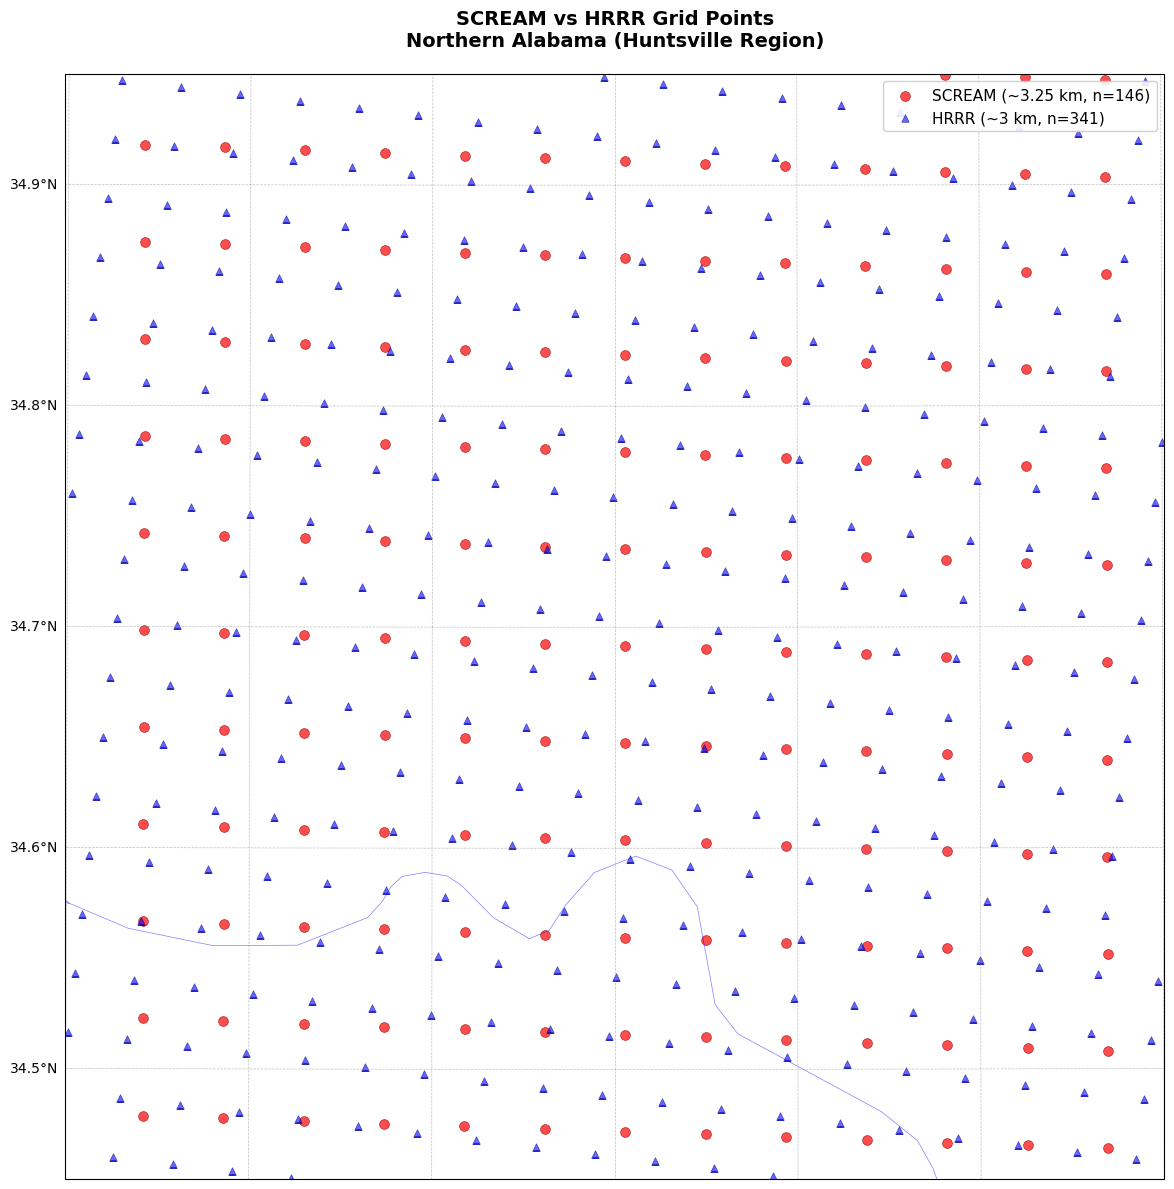

In [5]:
# Create figure with Lambert Conformal projection
# Use central coordinates for the projection
fig = plt.figure(figsize=(14, 12))

# Lambert Conformal Conic projection centered on the region
proj = ccrs.LambertConformal(
    central_longitude=lon_center,
    central_latitude=lat_center,
    standard_parallels=(33, 45)  # Standard parallels for CONUS
)

ax = plt.axes(projection=proj)

# Set map extent (in lat/lon coordinates)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=1.5, edgecolor='black')
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1)
ax.add_feature(cfeature.BORDERS.with_scale('10m'), linewidth=1)
ax.add_feature(cfeature.RIVERS.with_scale('10m'), linewidth=0.5, edgecolor='blue', alpha=0.5)
ax.add_feature(cfeature.LAKES.with_scale('10m'), edgecolor='blue', facecolor='lightblue', alpha=0.3)

# Plot grid points
# SCREAM: red circles
ax.scatter(
    scream_lon_subset, scream_lat_subset,
    c='red', s=50, marker='o', alpha=0.7,
    transform=ccrs.PlateCarree(),
    label=f'SCREAM (~3.25 km, n={len(scream_lat_subset)})',
    edgecolors='darkred', linewidths=0.5
)

# HRRR: blue triangles
ax.scatter(
    hrrr_lon_subset, hrrr_lat_subset,
    c='blue', s=30, marker='^', alpha=0.6,
    transform=ccrs.PlateCarree(),
    label=f'HRRR (~3 km, n={len(hrrr_lat_subset)})',
    edgecolors='darkblue', linewidths=0.5
)

# Add gridlines
gl = ax.gridlines(
    draw_labels=True, linewidth=0.5, color='gray',
    alpha=0.5, linestyle='--'
)
gl.top_labels = False
gl.right_labels = False

# Add legend
ax.legend(loc='upper right', fontsize=11, framealpha=0.9)

# Add title
plt.title(
    'SCREAM vs HRRR Grid Points\nNorthern Alabama (Huntsville Region)',
    fontsize=14, fontweight='bold', pad=20
)

plt.tight_layout()
plt.show()

## Calculate Grid Spacing Statistics

In [6]:
from scipy.spatial import distance

def calculate_nearest_neighbor_distance(lat, lon):
    """Calculate mean nearest neighbor distance in km."""
    if len(lat) < 2:
        return np.nan
    
    # Convert to radians for distance calculation
    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)
    
    # Use haversine-like approximation for small distances
    R = 6371.0  # Earth radius in km
    
    # For small region, use simple Euclidean approximation
    # Convert to km at this latitude
    lat_mean = np.mean(lat)
    km_per_deg_lat = 111.0
    km_per_deg_lon = 111.0 * np.cos(np.deg2rad(lat_mean))
    
    x = lon * km_per_deg_lon
    y = lat * km_per_deg_lat
    
    coords = np.column_stack([x, y])
    
    # Calculate pairwise distances
    dists = distance.cdist(coords, coords)
    
    # Set diagonal to infinity to exclude self-distances
    np.fill_diagonal(dists, np.inf)
    
    # Find minimum distance for each point
    min_dists = np.min(dists, axis=1)
    
    return np.mean(min_dists), np.std(min_dists)

# Calculate for SCREAM
scream_mean, scream_std = calculate_nearest_neighbor_distance(
    scream_lat_subset, scream_lon_subset
)
print(f"SCREAM grid spacing:")
print(f"  Mean nearest neighbor: {scream_mean:.2f} ± {scream_std:.2f} km")

# Calculate for HRRR (sample subset if too many points)
if len(hrrr_lat_subset) > 5000:
    # Randomly sample for efficiency
    idx = np.random.choice(len(hrrr_lat_subset), 5000, replace=False)
    hrrr_lat_sample = hrrr_lat_subset[idx]
    hrrr_lon_sample = hrrr_lon_subset[idx]
else:
    hrrr_lat_sample = hrrr_lat_subset
    hrrr_lon_sample = hrrr_lon_subset

hrrr_mean, hrrr_std = calculate_nearest_neighbor_distance(
    hrrr_lat_sample, hrrr_lon_sample
)
print(f"\nHRRR grid spacing:")
print(f"  Mean nearest neighbor: {hrrr_mean:.2f} ± {hrrr_std:.2f} km")

SCREAM grid spacing:
  Mean nearest neighbor: 4.01 ± 0.00 km

HRRR grid spacing:
  Mean nearest neighbor: 2.99 ± 0.00 km


## Close-up View of a Smaller Region

Zoom region points:
  SCREAM: 25
  HRRR: 54


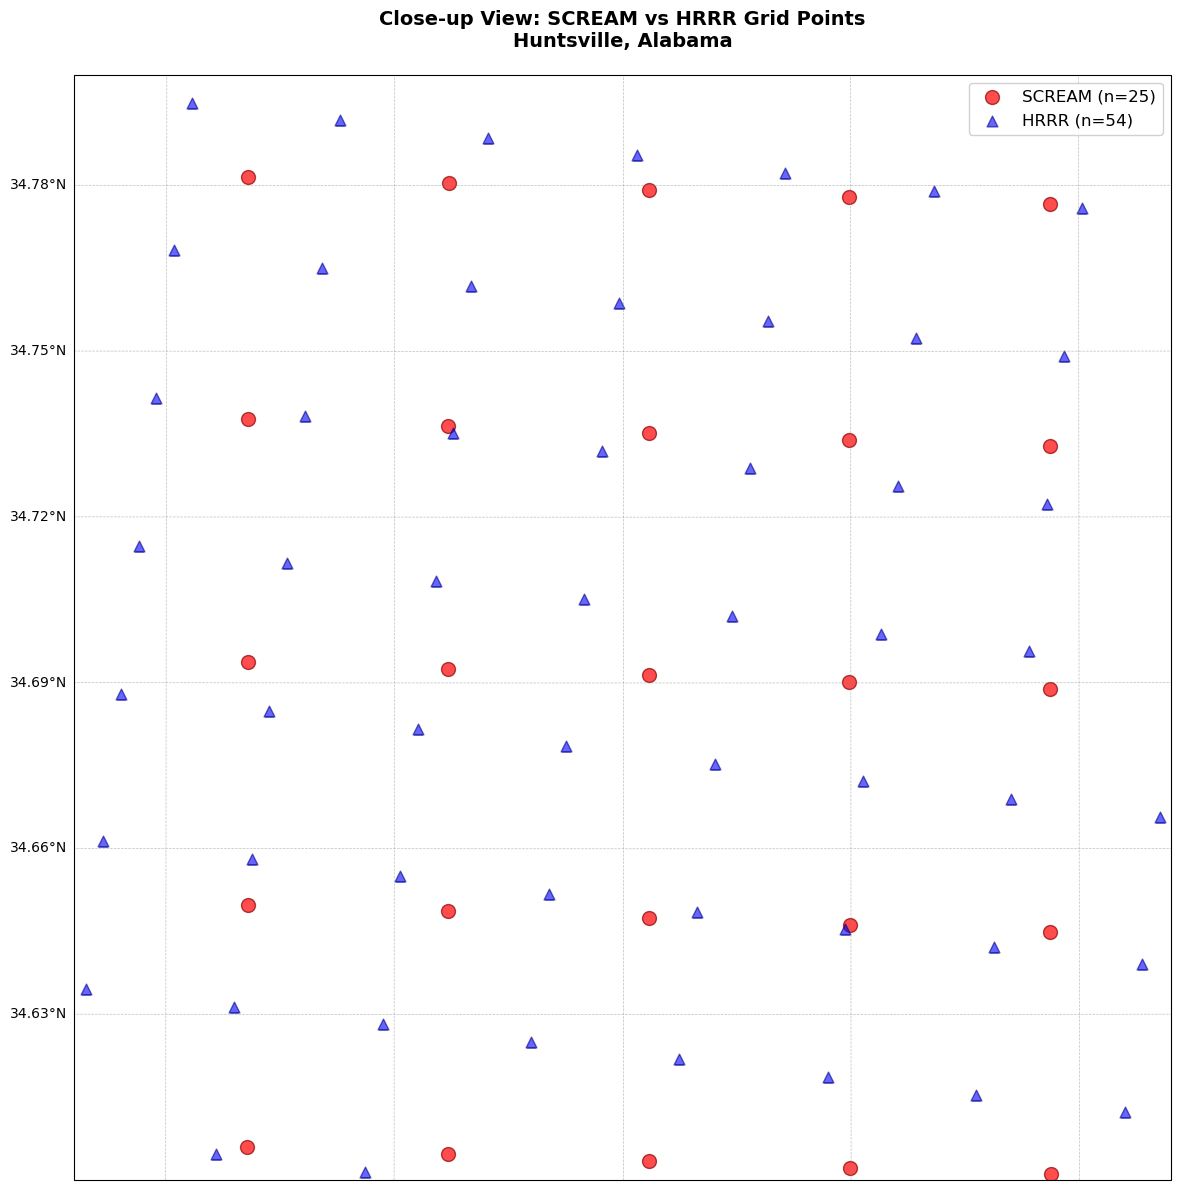

In [7]:
# Even smaller region for detailed view
lat_min_zoom = lat_center - 0.1
lat_max_zoom = lat_center + 0.1
lon_min_zoom = lon_center - 0.12
lon_max_zoom = lon_center + 0.12

# Filter points for zoom region
scream_mask_zoom = (
    (scream_lat >= lat_min_zoom) & (scream_lat <= lat_max_zoom) &
    (scream_lon >= lon_min_zoom) & (scream_lon <= lon_max_zoom)
)
scream_lat_zoom = scream_lat[scream_mask_zoom]
scream_lon_zoom = scream_lon[scream_mask_zoom]

hrrr_mask_zoom = (
    (hrrr_lat >= lat_min_zoom) & (hrrr_lat <= lat_max_zoom) &
    (hrrr_lon >= lon_min_zoom) & (hrrr_lon <= lon_max_zoom)
)
hrrr_lat_zoom = hrrr_lat[hrrr_mask_zoom]
hrrr_lon_zoom = hrrr_lon[hrrr_mask_zoom]

print(f"Zoom region points:")
print(f"  SCREAM: {len(scream_lat_zoom)}")
print(f"  HRRR: {len(hrrr_lat_zoom)}")

# Create zoomed map
fig = plt.figure(figsize=(14, 12))
proj = ccrs.LambertConformal(
    central_longitude=lon_center,
    central_latitude=lat_center,
    standard_parallels=(33, 45)
)
ax = plt.axes(projection=proj)
ax.set_extent([lon_min_zoom, lon_max_zoom, lat_min_zoom, lat_max_zoom], crs=ccrs.PlateCarree())

# Add features
ax.add_feature(cfeature.STATES.with_scale('10m'), linewidth=2, edgecolor='black')
ax.add_feature(cfeature.LAKES.with_scale('10m'), edgecolor='blue', facecolor='lightblue', alpha=0.3)
ax.add_feature(cfeature.RIVERS.with_scale('10m'), linewidth=0.5, edgecolor='blue', alpha=0.5)

# Plot with larger markers for better visibility
ax.scatter(
    scream_lon_zoom, scream_lat_zoom,
    c='red', s=100, marker='o', alpha=0.7,
    transform=ccrs.PlateCarree(),
    label=f'SCREAM (n={len(scream_lat_zoom)})',
    edgecolors='darkred', linewidths=1
)

ax.scatter(
    hrrr_lon_zoom, hrrr_lat_zoom,
    c='blue', s=60, marker='^', alpha=0.6,
    transform=ccrs.PlateCarree(),
    label=f'HRRR (n={len(hrrr_lat_zoom)})',
    edgecolors='darkblue', linewidths=1
)

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.legend(loc='upper right', fontsize=12, framealpha=0.9)
plt.title(
    'Close-up View: SCREAM vs HRRR Grid Points\nHuntsville, Alabama',
    fontsize=14, fontweight='bold', pad=20
)

plt.tight_layout()
plt.show()